In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.decomposition       import PCA
from sklearn.preprocessing       import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_regression
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


All libraries imported successfully.


In [9]:
X_raw, y_continuous = make_regression(
    n_samples=500,
    n_features=10,
    n_informative=7,
    noise=20,
    random_state=42
)


# ── 2. Bin continuous y into 3 discrete classes ───────────────────────────────
#    Low / Medium / High  (based on equal-frequency quantile bins)
y_binned, bin_edges = pd.cut(
    y_continuous,
    bins=3,
    labels=[0, 1, 2],   # 0=Low, 1=Medium, 2=High
    retbins=True
)
y = y_binned.astype(int)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]

dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic regression dataset via make_regression"
)

# Now this works exactly like any sklearn dataset
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')   # Feature matrix
y = df['target']

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)


pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_

print("Model trained on training set only.")


Model trained on training set only.


  Component      Variance Explained   Cumulative
  ----------------------------------------------
  PC1                       12.44%       12.44%
  PC2                       11.33%       23.78%
  PC3                       11.03%       34.81%
  PC4                       10.71%       45.51%
  PC5                       10.18%       55.70%
  PC6                        9.88%       65.58%
  PC7                        9.16%       74.74%
  PC8                        8.76%       83.50%
  PC9                        8.34%       91.84%
  PC10                       8.16%      100.00%


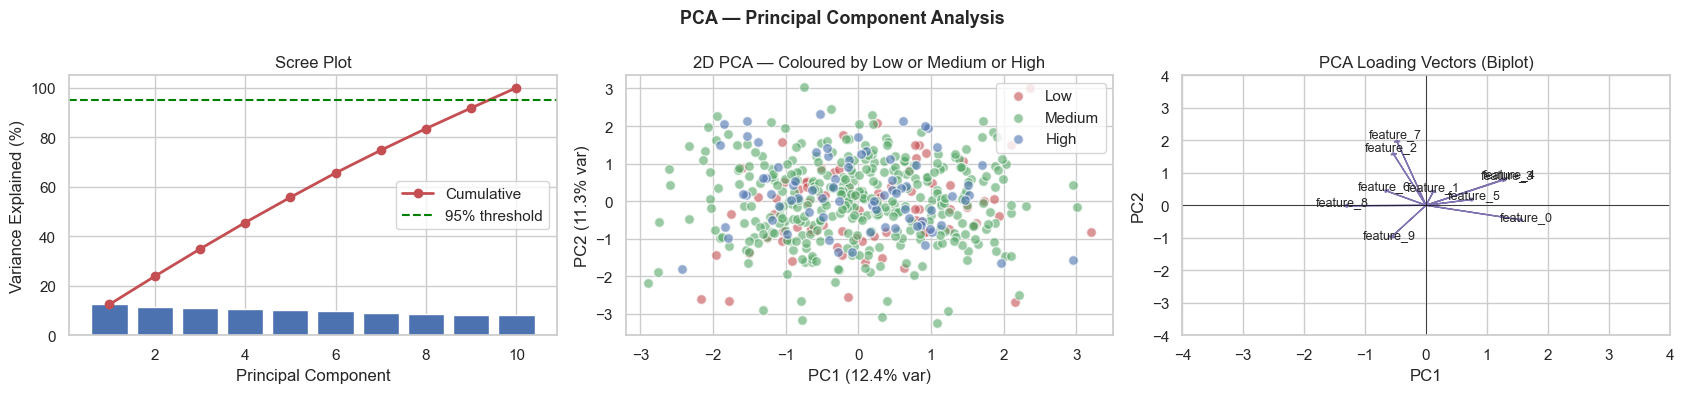

In [13]:

print(f"  {'Component':<12} {'Variance Explained':>20} {'Cumulative':>12}")
print(f"  {'-'*46}")
cum = 0
for i, ev in enumerate(explained):
    cum += ev
    print(f"  PC{i+1:<10} {ev*100:>18.2f}%  {cum*100:>10.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle("PCA — Principal Component Analysis", fontsize=13, fontweight="bold")

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained*100, color="#4C72B0", edgecolor="white")
axes[0].plot(range(1, len(explained)+1), np.cumsum(explained)*100, "r-o", lw=2, label="Cumulative")
axes[0].axhline(95, color="green", linestyle="--", lw=1.5, label="95% threshold")
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot"); axes[0].legend()

# 2D scatter
pca2    = PCA(n_components=2)
X_pca2  = pca2.fit_transform(X_scaled)
for label, name, color in [(0,"Low","#C44E52"), (1,"Medium","#55A868"), (2,"High","#4C72B0")]:
    mask = y == label
    axes[1].scatter(X_pca2[mask,0], X_pca2[mask,1],
                    label=name, color=color, alpha=0.6, edgecolors="white", s=50)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
axes[1].set_title("2D PCA — Coloured by Low or Medium or High"); axes[1].legend()

# Biplot
loading = pca2.components_.T
for i, feat in enumerate(feature_names):
    axes[2].arrow(0, 0, loading[i,0]*3, loading[i,1]*3,
                  head_width=0.1, head_length=0.05, fc="#8172B2", ec="#8172B2")
    axes[2].text(loading[i,0]*3.2, loading[i,1]*3.2, feat, fontsize=9, ha="center")
axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4)
axes[2].axhline(0, color="black", lw=0.5); axes[2].axvline(0, color="black", lw=0.5)
axes[2].set_title("PCA Loading Vectors (Biplot)")
axes[2].set_xlabel("PC1"); axes[2].set_ylabel("PC2")
plt.tight_layout(); plt.show()
